In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # 모델 저장용

# 모듈 자동 리로드 설정
%load_ext autoreload
%autoreload 2

# src 폴더 경로 설정
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# 공통 함수 모듈 임포트
from src import common_utils as utils
from src import config

# 머신러닝 관련 임포트
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             precision_recall_curve, roc_curve)

utils.log("✅ 환경 설정 완료")

[20:54:22] ✅ [Config] 환경 설정 완료 (OS: Darwin)
[20:54:22] ✅ 환경 설정 완료


In [3]:
# 1. 파일 경로 및 기간 설정
FILE_PATH = "../data/10_processed/df_sha.parquet"
TRAIN_MONTHS = [str(202300 + i) for i in range(2, 11)] # 2~10월 (학습)
TEST_MONTHS = ['202311', '202312']                     # 11~12월 (검증)

# 2. 데이터 로드
df = utils.load_parquet(FILE_PATH)

# 3. 전처리 (값 변환 -> 타입 변경 -> 이름 변경)
df = utils.data_preprocess(df)

# 4. 결측치 제거
df = df.dropna()
utils.log(f"✅ 전처리 및 결측치 제거 완료: {len(df):,}건")

[20:55:43] 📂 로드 완료: 22,473,534 Rows (Selected 39 Columns)
[20:55:43] 🚀 데이터 전처리(data_preprocess) 시작...
[20:56:10] ✨ 전처리 완료: 37개 컬럼 변환 및 정리됨
[20:56:21] ✅ 전처리 및 결측치 제거 완료: 19,363,972건


In [ ]:
target_col_name = 'derived_cancel_yn' # config에 맞게 수정

# 1. Train/Test 분리 및 다운샘플링
# sampling_ratio=1.0 (1:1 비율) -> 해지자 수만큼만 유지자를 남김 (Recall 극대화 전략)
X_train, y_train, X_test, y_test = utils.split_oot_dataset(
    df, 
    train_months=TRAIN_MONTHS, 
    test_months=TEST_MONTHS,
    target_col=target_col_name,
    sampling_ratio=1.0  # [중요] 1:1 비율 적용
)

print(f"📌 최종 학습 데이터(Train): {X_train.shape} (해지:유지 = 1:1)")
print(f"📌 최종 검증 데이터(Test):  {X_test.shape} (원본 비율 유지)")

[20:56:23] 🚀 데이터셋 분할(split_oot_dataset) 시작...
[20:56:34] 📊 분할 결과: Train 15,868,607건 (기간: 202302~202310), Test 3,495,365건
[20:56:41] ✂️ 다운샘플링 적용 (비율 1:1.0): Train 데이터가 1,838,060건으로 조정됨


📌 최종 학습 데이터(Train): (1838060, 36) (해지:유지 = 1:1)
📌 최종 검증 데이터(Test):  (3495365, 36) (원본 비율 유지)


In [ ]:
# [옵션] RFECV에서 선정된 특성 리스트 (예시)
# 만약 이전 단계에서 구한 리스트가 있다면 아래에 복사해서 넣으세요.
# 없다면 이 셀을 실행하지 않고 넘어가셔도 됩니다.

# SELECTED_FEATURES = [
#     'contract_remain_code', 'svc_duration_grp', 'derived_prod_nm_grp', ...
# ]

# if 'SELECTED_FEATURES' in locals():
#     X_train = X_train[SELECTED_FEATURES]
#     X_test = X_test[SELECTED_FEATURES]
#     print(f"🎯 선택된 {len(SELECTED_FEATURES)}개 특성만 사용하여 학습합니다.")
# else:
#     print("🚀 모든 특성을 사용하여 학습합니다.")

In [5]:
# 1. 컬럼 분류
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns

print(f"🔢 수치형 변수: {len(numeric_features)}개")
print(f"🔤 범주형 변수: {len(categorical_features)}개")

# 2. 전처리 파이프라인 (메모리 최적화)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
    ],
    verbose_feature_names_out=False
)

🔢 수치형 변수: 14개
🔤 범주형 변수: 22개


In [6]:
# ==========================================================
# 고도화 모델 정의 및 학습
# ==========================================================

# 1. 모델 정의 (성능 중심 설정)
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=1000,       # [상향] 트리 1000개 (충분한 학습)
    learning_rate=0.05,      # [하향] 꼼꼼하게 학습
    max_depth=6,             # 적절한 깊이
    subsample=0.8,           # 과적합 방지
    colsample_bytree=0.8,    # 과적합 방지
    eval_metric='logloss',
    enable_categorical=True, # 범주형 최적화
    n_jobs=-1
)

# 2. 파이프라인 생성
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])

print("🚀 Full Training 시작... (데이터 크기에 따라 시간이 소요됩니다)")
# 3. 학습
pipeline.fit(X_train, y_train)
print("✅ 학습 완료!")

🚀 Full Training 시작... (데이터 크기에 따라 시간이 소요됩니다)
✅ 학습 완료!


🔍 검증 데이터 예측 중...


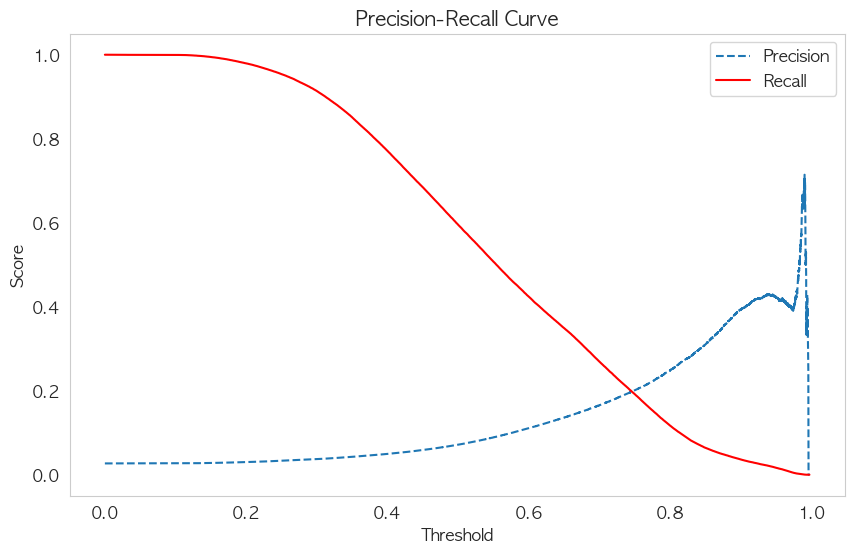

🎯 목표 Recall(65.0%)를 위한 최적 임계값: 0.4697

📊 최종 모델 성능 리포트 (Threshold: 0.4697)
✅ 정확도 (Accuracy):  0.7320
✅ 정밀도 (Precision): 0.0634
✅ 탐지율 (Recall):    0.6500 (★)
✅ F1 Score:          0.1155
✅ ROC AUC:           0.7649


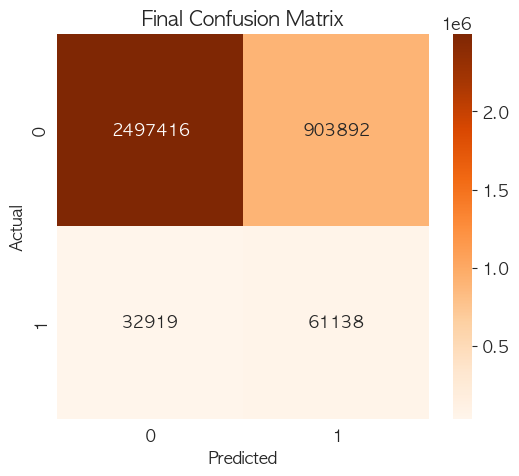

In [7]:
# ==========================================================
# 예측 및 Threshold Tuning
# ==========================================================

# 1. 예측 확률 계산
print("🔍 검증 데이터 예측 중...")
y_prob = pipeline.predict_proba(X_test)[:, 1]

# 2. Precision-Recall Curve 시각화
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], linestyle='--', label='Precision')
plt.plot(thresholds, recalls[:-1], color='red', label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

# 3. 목표 Recall 달성을 위한 최적 임계값 찾기
TARGET_RECALL = 0.65  # [목표] 해지자의 65% 이상 탐지
valid_indices = np.where(recalls >= TARGET_RECALL)[0]

if len(valid_indices) > 0:
    optimal_threshold = thresholds[valid_indices[-1]]
else:
    optimal_threshold = 0.5
    print("⚠️ 목표 Recall 달성 불가, 기본값(0.5) 사용")

print(f"🎯 목표 Recall({TARGET_RECALL*100}%)를 위한 최적 임계값: {optimal_threshold:.4f}")

# 4. 최적 임계값 적용
y_pred_tuned = (y_prob >= optimal_threshold).astype(int)

# 5. 최종 리포트
print("\n" + "="*50)
print(f"📊 최종 모델 성능 리포트 (Threshold: {optimal_threshold:.4f})")
print("="*50)

print(f"✅ 정확도 (Accuracy):  {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"✅ 정밀도 (Precision): {precision_score(y_test, y_pred_tuned):.4f}")
print(f"✅ 탐지율 (Recall):    {recall_score(y_test, y_pred_tuned):.4f} (★)")
print(f"✅ F1 Score:          {f1_score(y_test, y_pred_tuned):.4f}")
print(f"✅ ROC AUC:           {roc_auc_score(y_test, y_prob):.4f}")

# 혼동 행렬 시각화
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('Final Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
# 학습된 모델 저장 (나중에 재사용 가능)
model_dir = "../../models"
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, "xgb_churn_model_v1.pkl")

joblib.dump(pipeline, model_path)
print(f"💾 모델 저장 완료: {model_path}")